# 07-Hybrid Search & Reciprocal Rank Fusion (RRF)

In Lesson 05 and Lesson 06, we explored two wildly different paradigms of retrieval:

1. **Dense Retrieval (Bi-Encoders)**: Captures deep semantic abstraction and conceptual relationships, but can stumble on exact string literals, serial codes, and rare keywords.
2. **Sparse Retrieval (BM25)**: Targets exact lexical token overlaps with surgical precision, but completely fails to cross the "Lexical Gap" when synonyms or paraphrases are used.

In an production-grade Enterprise environment, choosing one over the other introduces an unacceptable architectural compromise. A user query like *"Fixing error 0x800F081F on my remote laptop"* demands both: **Sparse search** to lock onto the exact error hexadecimal code, and **Dense search** to understand the conceptual context of troubleshooting a remote workstation.

To build a resilient retrieval system, we must execute both paradigms simultaneously and merge their outputs. This structural paradigm is known as **Hybrid Search**.

However, merging these spaces presents a severe mathematical challenge: **How do you combine a dense vector cosine score (bounded between -1.0 and 1.0) with a sparse BM25 score (unbounded, often ranging from 0.0 to 50.0)?**

We will deconstruct the mathematical framework designed to solve this normalization crisis: **Reciprocal Rank Fusion (RRF)**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Hybrid Systems & Fusion Rank Environment Ready.")

✅ Hybrid Systems & Fusion Rank Environment Ready.


# 1. The Normalization Crisis: Score vs. Rank

A naive approach to hybrid search is **Score-Based Fusion**. If a document has a dense score $S_{dense}$ and a sparse score $S_{sparse}$, we could attempt a linear combination:

$$\text{Score}_{hybrid} = \alpha \cdot S_{dense} + (1 - \alpha) \cdot S_{sparse}$$

This is highly unstable in production. Cosine similarities are highly compressed (often clustering between $0.6$ and $0.8$ for modern embeddings), while BM25 scores scale aggressively based on document length and term frequency. A single long document with a heavily repeated keyword can yield a BM25 score of $45.0$, completely obliterating the dense vector component regardless of your $\alpha$ weight.

To circumvent this scaling mismatch, **Reciprocal Rank Fusion (RRF)** discards the raw scores entirely and operates strictly on the **relative positional ranks** of the documents.

# 2. The Mathematics of Reciprocal Rank Fusion (RRF)

RRF is a highly robust, parameter-light sorting algorithm that combines multiple ranked lists into a single unified output. Let $\mathcal{D}$ be the set of all documents, and $M$ be the set of retrieval systems (in our case, $M = \{\text{Dense}, \text{Sparse}\}$). For a given document $d$, let $r_m(d)$ be its exact 1-based rank position inside the output list of system $m$.

The RRF score for document $d$ is defined as:

$$RRF\_Score(d) = \sum_{m \in M} \frac{1}{k + r_m(d)}$$

Where $k$ is a positive constant hyperparameter (the standard baseline established by information retrieval literature is $k = 60$).

### The Role of the Smoothing Constant ($k$)

The constant $k$ dictates how aggressively the algorithm prioritizes top-ranked documents over low-ranked ones:

* If a document is ranked #1 by the Dense retriever ($r=1$), its score component is $\frac{1}{60 + 1} \approx 0.01639$.
* If it is ranked #50 ($r=50$), its score component drops to $\frac{1}{60 + 50} \approx 0.00909$.

The reciprocal function guarantees a high-penalty curve for low-ranking items while ensuring that a document that appears consistently at a moderate position across *both* systems easily outscores an item that wins #1 in one system but vanishes entirely from the other.

# 3. Architecting the Hybrid RRF Engine

Let's build an industrial RRF fusion matrix from scratch. We will pass mock outputs from a Dense Retriever and a Sparse Retriever, execute the reciprocal calculus, and observe how consensus items climb to the top.

In [2]:
# --- 🔀 The Reciprocal Rank Fusion Engine ---

class ReciprocalRankFusion:
    def __init__(self, k: int = 60):
        self.k = k

    def fuse(self, dense_results: List[str], sparse_results: List[str]) -> List[tuple]:
        """
        Takes two ordered lists of document IDs and computes their merged RRF scores.
        """
        rrf_scores = {}

        # 1. Process Dense Rankings (1-based index)
        for rank, doc_id in enumerate(dense_results, start=1):
            if doc_id not in rrf_scores:
                rrf_scores[doc_id] = 0.0
            rrf_scores[doc_id] += 1.0 / (self.k + rank)

        # 2. Process Sparse Rankings (1-based index)
        for rank, doc_id in enumerate(sparse_results, start=1):
            if doc_id not in rrf_scores:
                rrf_scores[doc_id] = 0.0
            rrf_scores[doc_id] += 1.0 / (self.k + rank)

        # 3. Sort the final combined documents by descending RRF score
        sorted_docs = sorted(rrf_scores.items(), key=lambda x: x[1], reverse=True)
        return sorted_docs

# Simulate an Enterprise Search Case
# Query: "Troubleshooting configuration error 0x800F081F on corporate laptops"

# Dense Model understands "Troubleshooting" and "corporate laptops" conceptually.
# It ranks documents based on semantic atmosphere.
dense_ordered_output = ["doc_B", "doc_A", "doc_C", "doc_D", "doc_E"]

# Sparse Model (BM25) locks onto the exact string "0x800F081F".
# It ranks documents containing the precise token.
sparse_ordered_output = ["doc_F", "doc_A", "doc_G", "doc_B", "doc_H"]

# Initialize Fusion Engine
rrf = ReciprocalRankFusion(k=60)
hybrid_results = rrf.fuse(dense_ordered_output, sparse_ordered_output)

print("--- 📊 Standalone System Perspectives ---")
print(f"Dense Ranking Priority:  {dense_ordered_output}")
print(f"Sparse Ranking Priority: {sparse_ordered_output}")

print("\n--- 🧬 Unified Hybrid RRF Rankings ---")
for rank, (doc_id, score) in enumerate(hybrid_results, start=1):
    # Determine the origin story of the document
    d_rank = dense_ordered_output.index(doc_id) + 1 if doc_id in dense_ordered_output else "Unranked"
    s_rank = sparse_ordered_output.index(doc_id) + 1 if doc_id in sparse_ordered_output else "Unranked"
    print(f"Rank {rank} | {doc_id} | RRF Score: {score:.5f} [Dense Rank: {d_rank}, Sparse Rank: {s_rank}]")

print("\n--- 💡 Engineering Insight ---")
print("Look closely at doc_A! It did not win the gold medal in either individual category (it was #2 in Dense and #2 in Sparse).")
print("However, because it achieved strong consensus across both retrieval systems, its reciprocal score outpaced doc_B (which fell off to #4 in sparse) and doc_F (which was completely missing from the dense evaluation). RRF naturally amplifies mutual consensus.")

--- 📊 Standalone System Perspectives ---
Dense Ranking Priority:  ['doc_B', 'doc_A', 'doc_C', 'doc_D', 'doc_E']
Sparse Ranking Priority: ['doc_F', 'doc_A', 'doc_G', 'doc_B', 'doc_H']

--- 🧬 Unified Hybrid RRF Rankings ---
Rank 1 | doc_A | RRF Score: 0.03226 [Dense Rank: 2, Sparse Rank: 2]
Rank 2 | doc_B | RRF Score: 0.03202 [Dense Rank: 1, Sparse Rank: 4]
Rank 3 | doc_F | RRF Score: 0.01639 [Dense Rank: Unranked, Sparse Rank: 1]
Rank 4 | doc_C | RRF Score: 0.01587 [Dense Rank: 3, Sparse Rank: Unranked]
Rank 5 | doc_G | RRF Score: 0.01587 [Dense Rank: Unranked, Sparse Rank: 3]
Rank 6 | doc_D | RRF Score: 0.01562 [Dense Rank: 4, Sparse Rank: Unranked]
Rank 7 | doc_E | RRF Score: 0.01538 [Dense Rank: 5, Sparse Rank: Unranked]
Rank 8 | doc_H | RRF Score: 0.01538 [Dense Rank: Unranked, Sparse Rank: 5]

--- 💡 Engineering Insight ---
Look closely at doc_A! It did not win the gold medal in either individual category (it was #2 in Dense and #2 in Sparse).
However, because it achieved strong con

# 4. Visualizing Rank Convergence Topology

To understand how the reciprocal formula rewards consensus over volatile single-system excellence, let's map out the decay curve of RRF scoring profiles across different document trajectories.

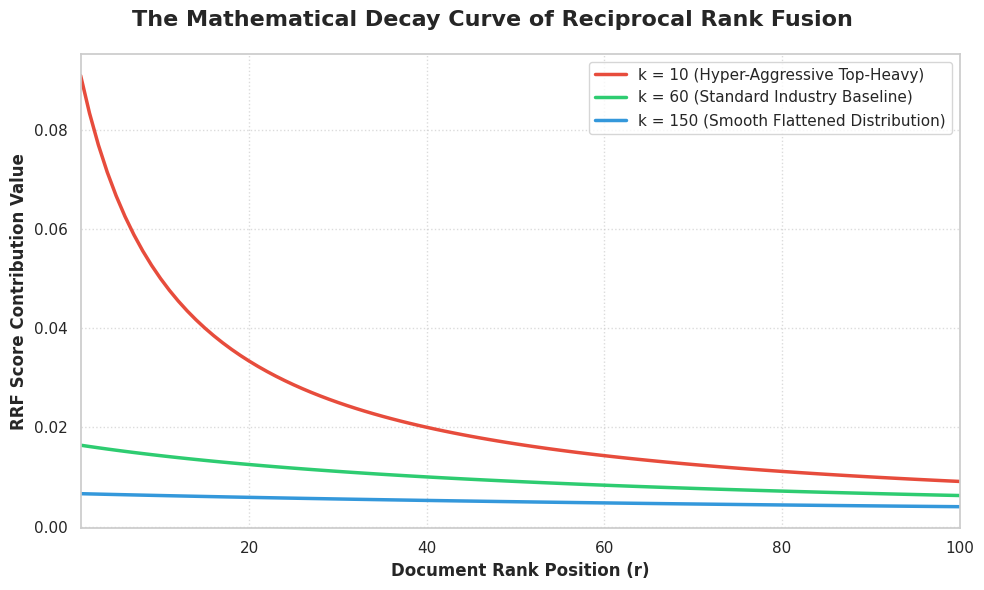

In [3]:
# Define mathematical range of rank positions
ranks = np.arange(1, 101)

# Compute RRF score contribution for a single system across different k constants
score_k10 = 1.0 / (10 + ranks)
score_k60 = 1.0 / (60 + ranks)
score_k150 = 1.0 / (150 + ranks)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("The Mathematical Decay Curve of Reciprocal Rank Fusion", fontsize=16, fontweight='bold')

ax.plot(ranks, score_k10, label="k = 10 (Hyper-Aggressive Top-Heavy)", linewidth=2.5, color='#e74c3c')
ax.plot(ranks, score_k60, label="k = 60 (Standard Industry Baseline)", linewidth=2.5, color='#2ecc71')
ax.plot(ranks, score_k150, label="k = 150 (Smooth Flattened Distribution)", linewidth=2.5, color='#3498db')

ax.set_xlabel("Document Rank Position (r)", fontsize=12, fontweight='bold')
ax.set_ylabel("RRF Score Contribution Value", fontsize=12, fontweight='bold')
ax.set_xlim(1, 100)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

### The Boardroom Consensus Protocol

Imagine an Enterprise corporation trying to select a new vendor for cloud infrastructure. To make an objective decision, the executive team recruits two distinct outside consultants:

1. **The Technical Auditor (The Sparse Retriever)**: Inspects hard checkboxes, rigid system logs, specific compliance code certificates, and raw pricing limits.
2. **The Culture & Strategy Consultant (The Dense Retriever)**: Evaluates developer workflow harmony, long-term strategic alignment, and overall team capability.

The consultants evaluate the candidate vendors and submit their top priority lists:

* The Technical Auditor ranks **Vendor F** as #1 because they match an exact compliance key, but leaves **Vendor A** at #2.
* The Strategy Consultant ranks **Vendor B** as #1 because of their cultural fit, but places **Vendor A** at #2.

If the corporation relies on a raw scoring matrix, the individual consultants will end up arguing over how much "cultural points" map to "compliance certificates."

Instead, the board uses the **Reciprocal Rank Fusion rule**: They look at the rank placements. Since **Vendor A** is strongly recommended as the #2 choice by both experts, it represents a safe, highly resilient corporate consensus. It wins the contract over Vendor F and Vendor B because it completely minimizes the structural risk of a blind spot from either consultant.